**Harris Corner**

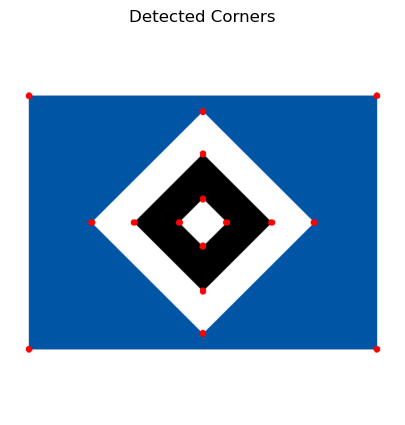

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('hsv.png', cv2.IMREAD_COLOR)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = np.float32(gray)

harris_response = cv2.cornerHarris(gray, blockSize=3, ksize=3, k=0.04)
harris_response = cv2.dilate(harris_response, None)

threshold = 0.01 * harris_response.max()
corner_image = img.copy()
keypoints = np.argwhere(harris_response > threshold)

for y, x in keypoints:
    cv2.circle(corner_image, (x, y), radius=5, color=(0, 0, 255), thickness=2)

plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(corner_image, cv2.COLOR_BGR2RGB))
plt.title("Detected Corners")
plt.axis("off")
plt.show()


**Hough Transform**

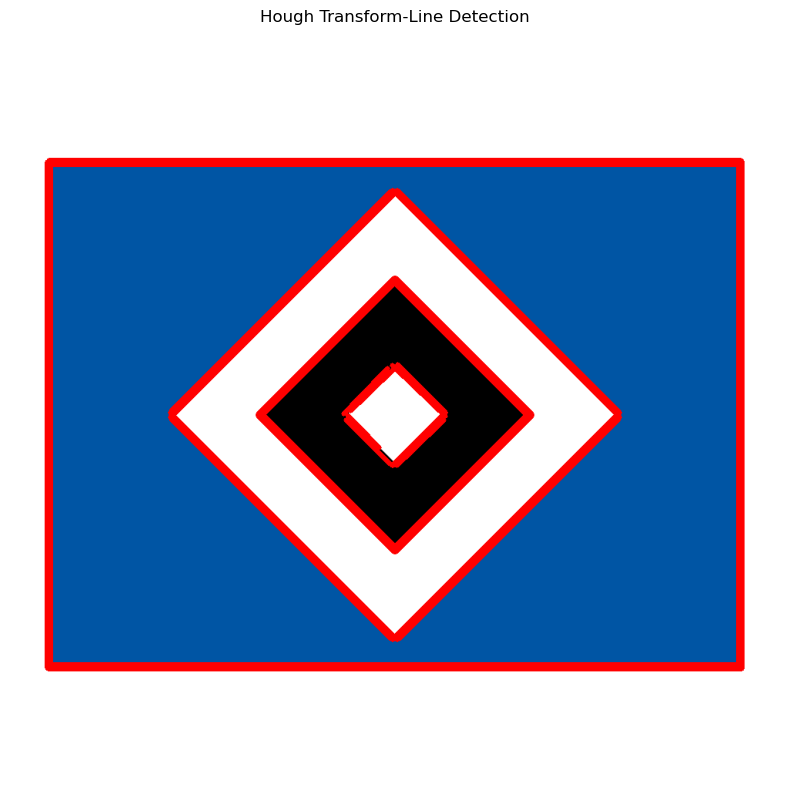

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('hsv.png', cv2.IMREAD_COLOR)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
binary = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
edges = cv2.Canny(binary, 50, 150)
lines = cv2.HoughLinesP(edges, 1, np.pi/180, 50, minLineLength=20, maxLineGap=20)

if lines is not None:
    for line in lines:
        x1, y1, x2, y2 = line[0]
        cv2.line(img, (x1, y1), (x2, y2), (0, 0, 255), 5)

plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Hough Transform-Line Detection")
plt.show()
